# Unsupervised surgery pipeline with SysVI

In [1]:
import os
os.chdir('../')
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import scanpy as sc
import torch
import scarches as sca
from scarches.dataset.trvae.data_handling import remove_sparsity
import matplotlib.pyplot as plt
import numpy as np
import gdown
import tempfile

/home/icb/chelseaalexandra.bri/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [3]:
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

### Set relevant anndata.obs labels


In [4]:
system_key = "system" #mouse vs human
batch_key = "batch"
cell_type_key = 'cell_type_eval'
ref_path = "sysvi_reference"

### Download Dataset and split into reference dataset and query dataset

In [5]:
# Load data
# Save dir may be changed as desired
save_dir = tempfile.TemporaryDirectory()
adata_path = os.path.join(save_dir.name, "mouse-human_pancreas_subset10000.h5ad")
adata = sc.read(
    adata_path,
    backup_url="https://github.com/theislab/cross_system_integration/raw/main/tutorials/data/mouse-human_pancreas_subset10000.h5ad",
)
adata

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38.2M/38.2M [00:00<00:00, 270MB/s]


AnnData object with n_obs × n_vars = 10000 × 1768
    obs: 'batch', 'mm_study', 'mm_sex', 'mm_age', 'mm_study_sample_design', 'mm_hc_gene_programs_parsed', 'mm_leiden_r1.5_parsed', 'cell_type_eval', 'system', 'hs_Sex', 'hs_Diabetes Status', 'leiden_system'
    var: 'gs_mm', 'gs_hs'
    obsm: 'X_pca_system'
    layers: 'counts'

In [6]:
target_adata = adata[
    (adata.obs['system'] == 0) &
    (adata.obs['batch'].isin(['VSG_MUC13632','STZ_G6','Fltp_P16_145_mGFP']))
].copy()

In [7]:
source_adata=adata[
    ~adata.obs_names.isin(target_adata.obs_names)
].copy()

### Train SysVI model

In [8]:
# On normalized and log-transformed data as recommended in https://docs.scvi-tools.org/en/1.3.3/tutorials/notebooks/scrna/sysVI.html
# Setup adata for training
sca.models.SysVI.setup_anndata(
    adata=source_adata,
    batch_key=system_key,
    categorical_covariate_keys=[batch_key]
)

vae = sca.models.SysVI(
    adata=source_adata,
    embed_categorical_covariates=True
)

# Example showing how to adjust loss weights
vae.train(check_val_every_n_epoch=1)

INFO     The model has been initialized                                                                            


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [07:37<00:00,  1.10s/it, v_num=1, train_loss=-1.5e+3]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [07:37<00:00,  1.14s/it, v_num=1, train_loss=-1.5e+3]


In [9]:
vae.save(ref_path, overwrite=True)

### Map query

In [79]:
# Perform surgery on reference model and train on query dataset
model = sca.models.SysVI.load_query_data(
    target_adata,
    ref_path,
    freeze_dropout = True,
    transfer_batch=True
)

INFO     File sysvi_reference/model.pt already downloaded                                                          
INFO     The model has been initialized                                                                            


In [80]:
model.train(max_epochs=10, plan_kwargs=dict(weight_decay=0.0))

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 10/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  4.44it/s, v_num=1, train_loss=-1.35e+3]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.94it/s, v_num=1, train_loss=-1.35e+3]


### Get latent representation of reference + query dataset and compute UMAP

In [82]:
latent_source = model.get_latent_representation(source_adata)
latent_target = model.get_latent_representation(target_adata)

full_latent = sc.AnnData(np.vstack([latent_source, latent_target]))
full_latent.obs['cell_type'] = adata_full.obs[cell_type_key].tolist()
full_latent.obs['system'] = adata_full.obs[system_key].tolist()

n_source = latent_source.shape[0]
n_target = latent_target.shape[0]

full_latent.obs["ref_query"] = (
    ["reference"] * n_source +
    ["query"] * n_target
)


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


<Figure size 320x320 with 0 Axes>

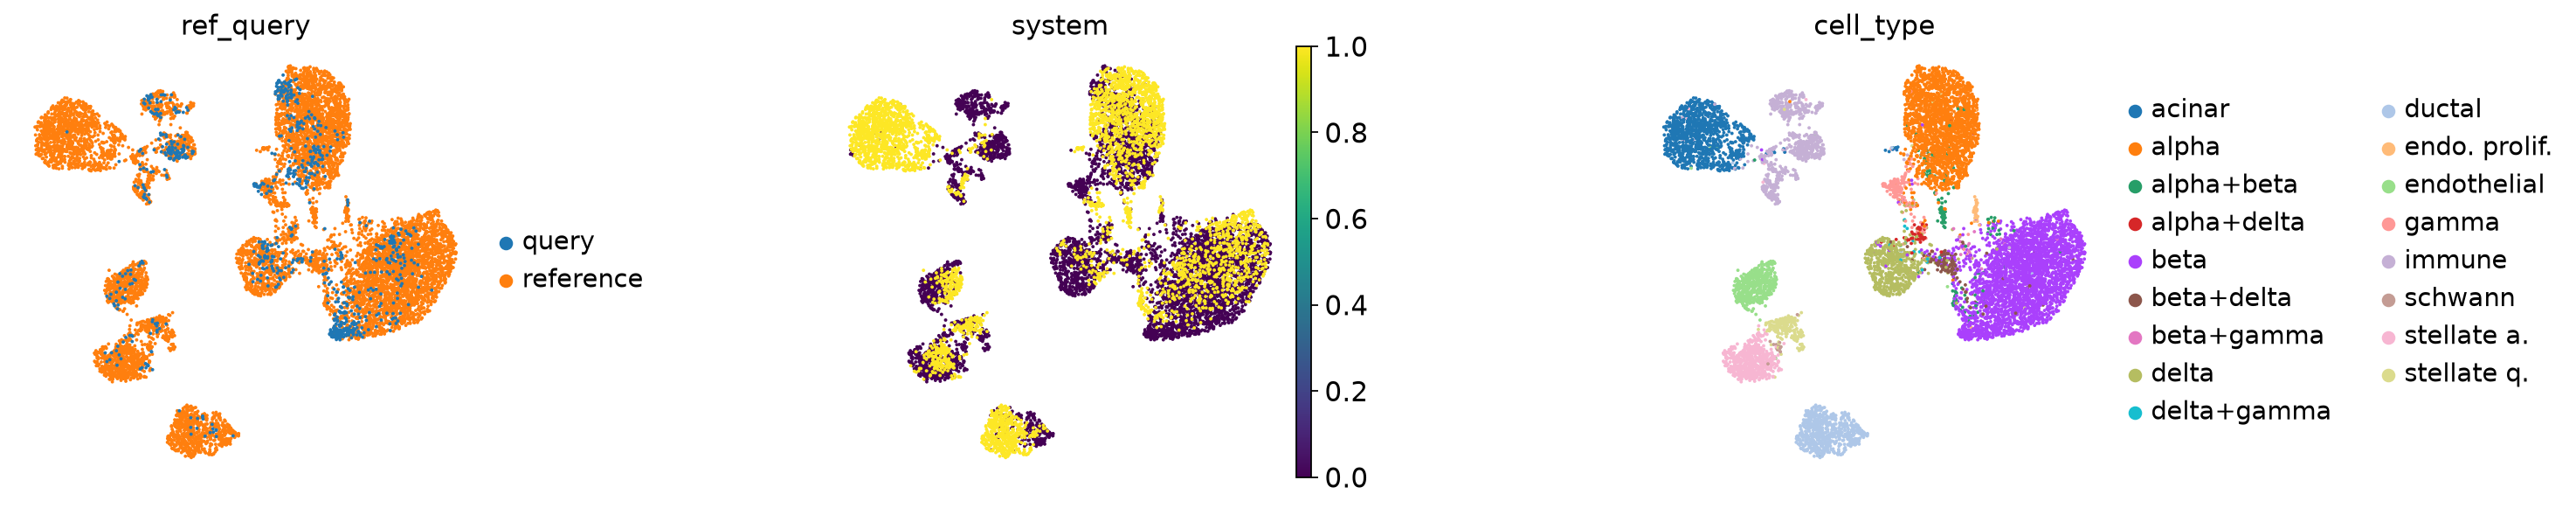

In [83]:
sc.pp.neighbors(full_latent)
sc.tl.leiden(full_latent)
sc.tl.umap(full_latent)
plt.figure()
sc.pl.umap(
    full_latent,
    color=["ref_query","system", "cell_type"],
    frameon=False,
    wspace=0.6,
)